# 13 Figure 2 Dataset Structure

Purpose:
This notebook prepares the draft plots and exported data for Figure 2.

Figure 2A:
- mechanism_simple vs log(P_est)

Figure 2B:
- structure_class vs log(P_est)

Figure 2C:
- ion_type vs log(P_est)

Figure 2D:
- descriptor association map
- mixed correlation / effect-size summary

The plots generated here are draft plots for inspection. Final figure panels will be redrawn in Igor Pro.

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# Output folder
out_dir = Path("../results/figure2_dataset_structure")
out_dir.mkdir(parents=True, exist_ok=True)

print("Output folder:", out_dir.resolve())

Output folder: C:\Users\wenlu\OneDrive\books_coding\Python_Projects\hydrovoltaic-ml\results\figure2_dataset_structure


In [80]:
data_path = Path("hydrovoltaic_dataset_phase2_input_utf8.csv")

df = pd.read_csv(data_path, encoding="utf-8-sig")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (159, 52)


,paper_doi,review_covered,ref_year,device_structure,built_in_asymmetry,asymmetry_origin,primary_mobile_ion,secondary_ion_present,secondary_mobile_ion,ion_origin,auxiliary_redox_present,continuous_output,water_interaction_mode,rh_percent,inorganic_electrolyte_present,inorganic_electrolyte_type,inorganic_electrolyte_concentration_wt%,polyelectrolyte_present,active_material_raw,material_class,structure_class,ionic_groups,top_electrode,bottom_electrode,electrode_symmetry,metal_electrode,voc_V,jsc_uA_cm2,power_density_uW_cm2,internal_resistance_Mohm,output_timescale_class,stability_time_min,dominant_mechanism,has_anionic,has_cationic,has_zwitterionic,polyelectrolyte_anionic_raw,polyelectrolyte_cationic_raw,polyelectrolyte_zwitterionic_raw,has_any_polyelectrolyte,estimated_power_density_uW_cm2,log_estimated_power_density,ion_type,asym_env,asym_chem,asym_electrode,mechanism_simple,ion_from_material,ion_from_electrolyte,ion_from_water,log_internal_resistance_Mohm,has_internal_resistance
0,10.1038/nnano.2016.300,1,2017,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,60.0,0,NaN,NaN,0,Carbon Black (CB),carbon,porous,"carboxyl, hydroxyl",CNT,CNT,1,0.0,1.00,0.0150,0.0053,8.0,days,11520.0,streaming,0,0,0,NaN,NaN,NaN,0,0.003750,-2.425853,proton,1,0,0,streaming,1,0,0,0.903090,1
1,10.1021/acsaelm.9b00419,1,2019,in-plane,0,environmental_gradient,OH-,1,H+,water_dissociation,0,1,evaporation_driven,62.0,0,NaN,NaN,0,ZnO,metal oxide,porous,hydroxyl,Al,Al,1,1.0,0.40,0.0200,0.0020,34.3,hours,120.0,streaming,0,0,0,NaN,NaN,NaN,0,0.002000,-2.698753,anion,1,0,0,streaming,0,0,1,1.535294,1
2,10.1002/adma.202514202,0,2026,in-plane,1,chemical + environmental,OH-,1,H+,water_dissociation,0,1,evaporation_driven,NaN,0,NaN,NaN,0,lanthanum iron perovskite oxide,semiconductor,porous,hydroxyl,CNT,CNT,1,0.0,1.50,0.0250,0.0094,60.0,days,12000.0,streaming,0,0,0,NaN,NaN,NaN,0,0.009375,-2.027982,anion,1,1,0,streaming,0,0,1,1.778151,1
3,10.1016/j.joule.2022.02.002,1,2022,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,NaN,0,NaN,NaN,0,Carbon Black (CB),carbon,porous,"carboxyl, hydroxyl",CNT,CNT,1,0.0,0.85,0.0368,NaN,NaN,hours,720.0,streaming,0,0,0,NaN,NaN,NaN,0,0.007820,-2.106738,proton,1,0,0,streaming,1,0,0,NaN,0
4,10.1016/j.ceramint.2023.05.033,0,2023,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,55.0,0,NaN,NaN,0,carbonized rice husk,carbon,porous,"carboxyl, hydroxyl, silanol",CNT,CNT,1,0.0,0.16,0.0400,NaN,NaN,hours,600.0,streaming,0,0,0,NaN,NaN,NaN,0,0.001600,-2.795609,proton,1,0,0,streaming,1,0,0,NaN,0


In [81]:
cols_to_check = [
    "mechanism_simple",
    "structure_class",
    "ion_type",
    "log_estimated_power_density",
    "estimated_power_density_uW_cm2",
    "log_internal_resistance_Mohm"
]

for c in cols_to_check:
    print(f"{c:35s}", c in df.columns)

mechanism_simple                    True
structure_class                     True
ion_type                            True
log_estimated_power_density         True
estimated_power_density_uW_cm2      True
log_internal_resistance_Mohm        True


In [82]:
# Create clean plotting dataframe
plot_df = df.copy()

# Keep only rows with target available
plot_df = plot_df.dropna(subset=["log_estimated_power_density"]).copy()

# Standardize string columns for plotting
for c in ["mechanism_simple", "structure_class", "ion_type"]:
    plot_df[c] = (
        plot_df[c]
        .astype(str)
        .str.strip()
        .replace({
            "nan": np.nan,
            "None": np.nan,
            "": np.nan
        })
    )

print("Plotting dataset shape:", plot_df.shape)
plot_df[["mechanism_simple", "structure_class", "ion_type", "log_estimated_power_density"]].head()

Plotting dataset shape: (159, 52)


,mechanism_simple,structure_class,ion_type,log_estimated_power_density
0,streaming,porous,proton,-2.425853
1,streaming,porous,anion,-2.698753
2,streaming,porous,anion,-2.027982
3,streaming,porous,proton,-2.106738
4,streaming,porous,proton,-2.795609


In [83]:
# Quick category counts
print("Mechanism counts")
print(plot_df["mechanism_simple"].value_counts(dropna=False))
print()

print("Structure counts")
print(plot_df["structure_class"].value_counts(dropna=False))
print()

print("Ion type counts")
print(plot_df["ion_type"].value_counts(dropna=False))

Mechanism counts
mechanism_simple
ion_gradient    107
streaming        52
Name: count, dtype: int64

Structure counts
structure_class
porous               118
film                  22
hydrogel              14
hydrogel + porous      4
hydrogel + film        1
Name: count, dtype: int64

Ion type counts
ion_type
proton          96
other_cation    54
anion            9
Name: count, dtype: int64


## Figure 2A

In [84]:
fig2A_df = plot_df[["mechanism_simple", "log_estimated_power_density"]].dropna().copy()
fig2A_df = fig2A_df.rename(columns={"log_estimated_power_density": "log_P_est"})

display(fig2A_df.head())
display(fig2A_df["mechanism_simple"].value_counts())

,mechanism_simple,log_P_est
0,streaming,-2.425853
1,streaming,-2.698753
2,streaming,-2.027982
3,streaming,-2.106738
4,streaming,-2.795609


mechanism_simple
ion_gradient    107
streaming        52
Name: count, dtype: int64

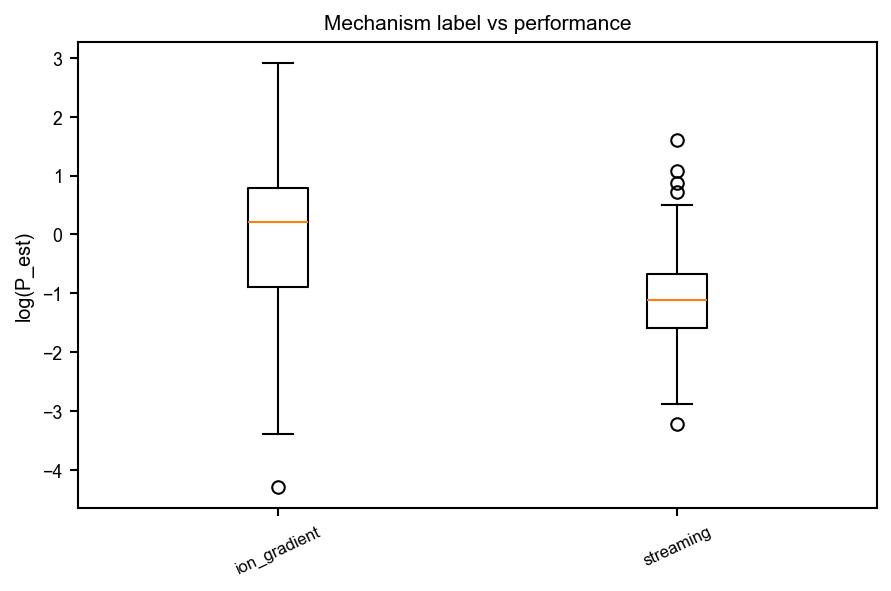

In [85]:
# Draft plot for Fig. 2A

# 先用 boxplot，后面你在 Igor 里再决定是否做 violin + box。
mechanism_order = fig2A_df["mechanism_simple"].value_counts().index.tolist()

data_mech = [
    fig2A_df.loc[fig2A_df["mechanism_simple"] == cat, "log_P_est"].values
    for cat in mechanism_order
]

plt.figure(figsize=(6, 4))
plt.boxplot(data_mech, tick_labels=mechanism_order, patch_artist=False)
plt.ylabel("log(P_est)")
plt.title("Mechanism label vs performance")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## Figure 2B

In [86]:

fig2B_df = plot_df[["structure_class", "log_estimated_power_density"]].dropna().copy()
fig2B_df = fig2B_df.rename(columns={"log_estimated_power_density": "log_P_est"})

display(fig2B_df.head())
display(fig2B_df["structure_class"].value_counts())

,structure_class,log_P_est
0,porous,-2.425853
1,porous,-2.698753
2,porous,-2.027982
3,porous,-2.106738
4,porous,-2.795609


structure_class
porous               118
film                  22
hydrogel              14
hydrogel + porous      4
hydrogel + film        1
Name: count, dtype: int64

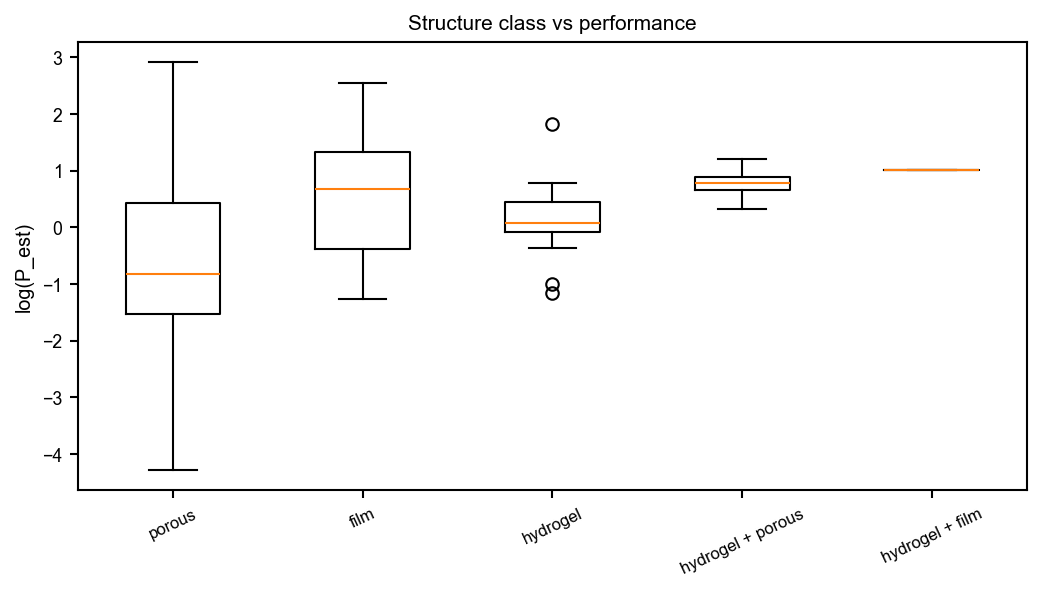

In [87]:
# Draft plot for Fig. 2B
structure_order = fig2B_df["structure_class"].value_counts().index.tolist()

data_struct = [
    fig2B_df.loc[fig2B_df["structure_class"] == cat, "log_P_est"].values
    for cat in structure_order
]

plt.figure(figsize=(7, 4))
plt.boxplot(data_struct, tick_labels=structure_order, patch_artist=False)
plt.ylabel("log(P_est)")
plt.title("Structure class vs performance")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## Figure 2C

In [88]:
fig2C_df = plot_df[["ion_type", "log_estimated_power_density"]].dropna().copy()
fig2C_df = fig2C_df.rename(columns={"log_estimated_power_density": "log_P_est"})

display(fig2C_df.head())
display(fig2C_df["ion_type"].value_counts())

,ion_type,log_P_est
0,proton,-2.425853
1,anion,-2.698753
2,anion,-2.027982
3,proton,-2.106738
4,proton,-2.795609


ion_type
proton          96
other_cation    54
anion            9
Name: count, dtype: int64

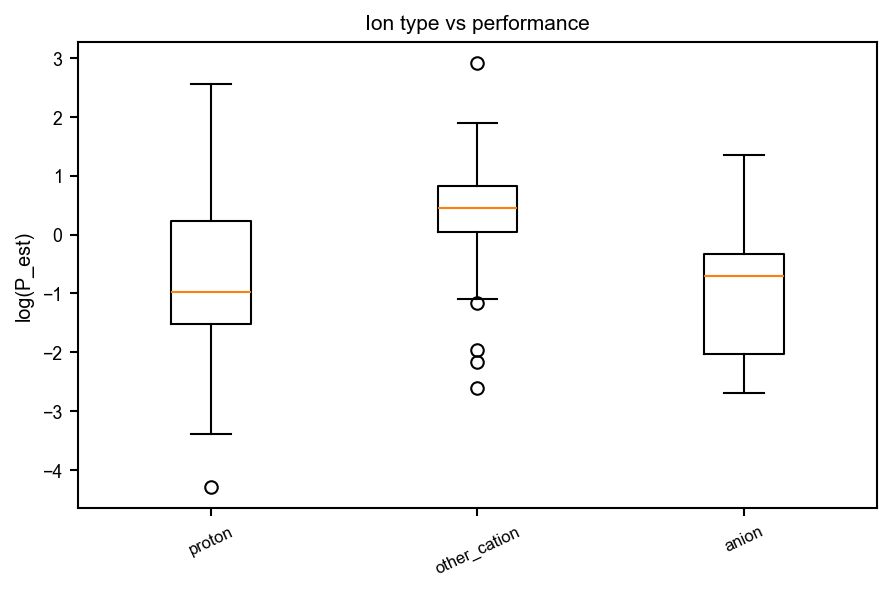

In [89]:
# Draft plot for Fig. 2C
ion_order = fig2C_df["ion_type"].value_counts().index.tolist()

data_ion = [
    fig2C_df.loc[fig2C_df["ion_type"] == cat, "log_P_est"].values
    for cat in ion_order
]

plt.figure(figsize=(6, 4))
plt.boxplot(data_ion, tick_labels=ion_order, patch_artist=False)
plt.ylabel("log(P_est)")
plt.title("Ion type vs performance")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## Figure 2A–C combined draft

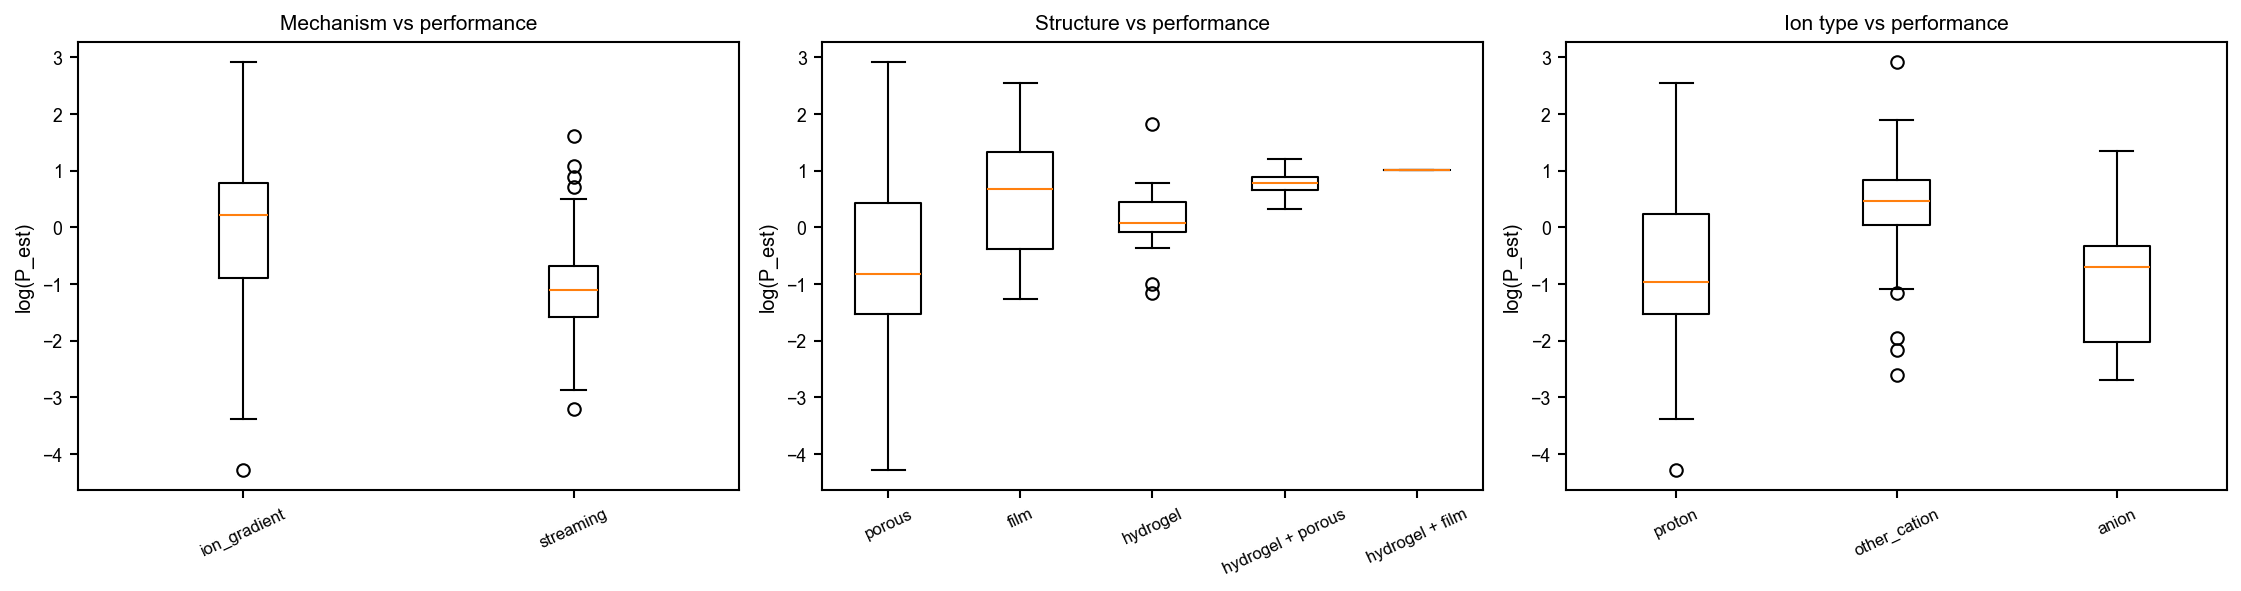

In [90]:
# Combined draft figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# A
axes[0].boxplot(data_mech, tick_labels=mechanism_order, patch_artist=False)
axes[0].set_title("Mechanism vs performance")
axes[0].set_ylabel("log(P_est)")
axes[0].tick_params(axis="x", rotation=25)

# B
axes[1].boxplot(data_struct, tick_labels=structure_order, patch_artist=False)
axes[1].set_title("Structure vs performance")
axes[1].set_ylabel("log(P_est)")
axes[1].tick_params(axis="x", rotation=25)

# C
axes[2].boxplot(data_ion, tick_labels=ion_order, patch_artist=False)
axes[2].set_title("Ion type vs performance")
axes[2].set_ylabel("log(P_est)")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

## Figure 2D — association map
这里先做一个 draft correlation/effect-size table。
真正最漂亮的 heatmap 我们后面还可以再 refine。

In [91]:
# Build numeric helper variables
assoc_df = plot_df.copy()

# Target
assoc_df["log_P_est"] = assoc_df["log_estimated_power_density"]

# Mechanism dummy: streaming = 1, ion_gradient = 0
assoc_df["mech_streaming"] = np.where(assoc_df["mechanism_simple"] == "streaming", 1,
                               np.where(assoc_df["mechanism_simple"] == "ion_gradient", 0, np.nan))

# Ion-type dummies
assoc_df["ion_proton"] = np.where(assoc_df["ion_type"] == "proton", 1, 0)
assoc_df["ion_other_cation"] = np.where(assoc_df["ion_type"] == "other_cation", 1, 0)
assoc_df["ion_anion"] = np.where(assoc_df["ion_type"] == "anion", 1, 0)

# Structure dummies
for cat in assoc_df["structure_class"].dropna().unique():
    safe_name = cat.replace(" ", "_").replace("+", "plus").replace("/", "_")
    assoc_df[f"struct_{safe_name}"] = np.where(assoc_df["structure_class"] == cat, 1, 0)

# Internal resistance if available
if "log_internal_resistance_Mohm" in assoc_df.columns:
    assoc_df["log_R"] = assoc_df["log_internal_resistance_Mohm"]

In [92]:
# Correlation table for Fig. 2D， 这里先做和 log_P_est 的单变量相关性预览。
candidate_cols = [
    "mech_streaming",
    "ion_proton",
    "ion_other_cation",
    "ion_anion"
]

# Add structure dummy columns
candidate_cols += [c for c in assoc_df.columns if c.startswith("struct_")]

# Add log_R if available
if "log_R" in assoc_df.columns:
    candidate_cols.append("log_R")

assoc_rows = []

for c in candidate_cols:
    tmp = assoc_df[[c, "log_P_est"]].dropna()
    if len(tmp) >= 3:
        r = tmp[c].corr(tmp["log_P_est"])
    else:
        r = np.nan
    
    assoc_rows.append({
        "descriptor": c,
        "n": len(tmp),
        "corr_with_log_P_est": r
    })

assoc_table = pd.DataFrame(assoc_rows).sort_values("corr_with_log_P_est", ascending=False)

display(assoc_table)


,descriptor,n,corr_with_log_P_est
2,ion_other_cation,159,0.393399
5,struct_film,159,0.274246
7,struct_hydrogel_plus_porous,159,0.139858
6,struct_hydrogel,159,0.119575
8,struct_hydrogel_plus_film,159,0.083501
3,ion_anion,159,-0.099011
1,ion_proton,159,-0.334128
0,mech_streaming,159,-0.358076
4,struct_porous,159,-0.359074
9,log_R,112,-0.541380


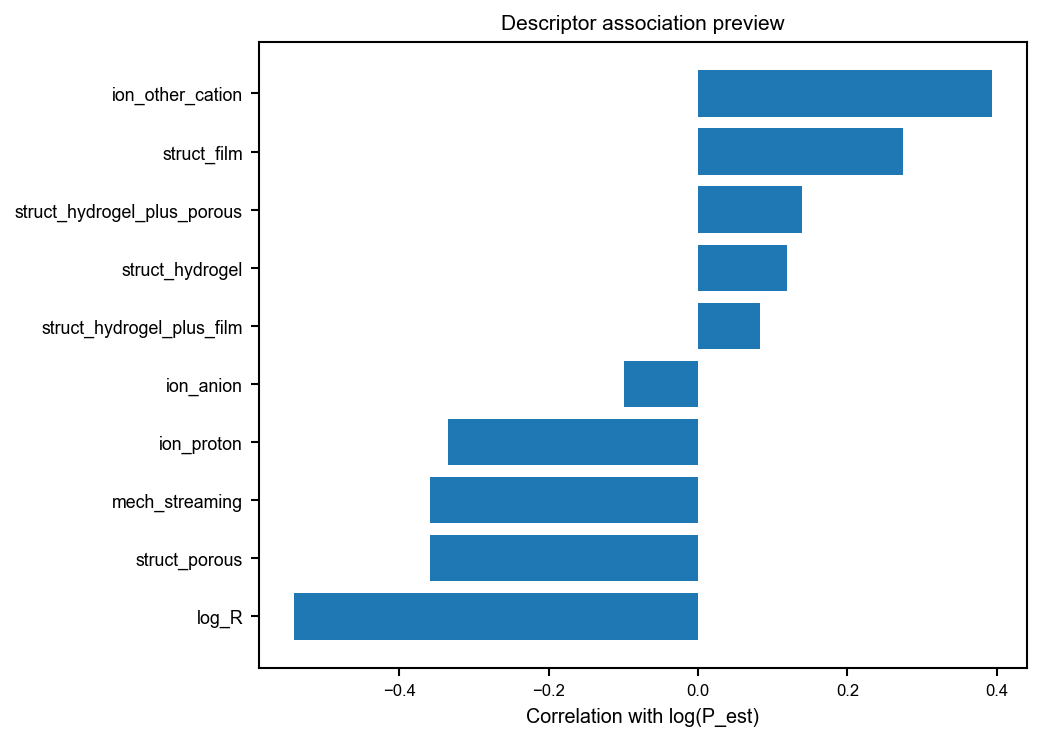

In [93]:
# Draft bar plot for Fig. 2D， 这是一个过渡版本。后面如果你觉得不够像 “association map”，我们再改成真正的 heatmap。
plot_assoc = assoc_table.dropna().copy()
plot_assoc = plot_assoc.sort_values("corr_with_log_P_est", ascending=True)

plt.figure(figsize=(7, 5))
plt.barh(plot_assoc["descriptor"], plot_assoc["corr_with_log_P_est"])
plt.xlabel("Correlation with log(P_est)")
plt.title("Descriptor association preview")
plt.tight_layout()
plt.show()

In [94]:
fig2A_df.to_csv(out_dir / "fig2A_mechanism_vs_logPest.csv", index=False, encoding="utf-8-sig")
fig2B_df.to_csv(out_dir / "fig2B_structure_vs_logPest.csv", index=False, encoding="utf-8-sig")
fig2C_df.to_csv(out_dir / "fig2C_iontype_vs_logPest.csv", index=False, encoding="utf-8-sig")
assoc_table.to_csv(out_dir / "fig2D_descriptor_association_table.csv", index=False, encoding="utf-8-sig")

print("Exported files:")
for f in out_dir.glob("*.csv"):
    print(f.name)

Exported files:
fig2A_mechanism_vs_logPest.csv
fig2B_structure_vs_logPest.csv
fig2C_iontype_vs_logPest.csv
fig2D_descriptor_association_heatmap.csv
fig2D_descriptor_association_table.csv


## Summary

This notebook prepares draft plots and exported data for Figure 2.

- Fig. 2A: mechanism label vs log(P_est)
- Fig. 2B: structure class vs log(P_est)
- Fig. 2C: ion type vs log(P_est)
- Fig. 2D: descriptor association preview

The exported CSV files will be used for final redrawing in Igor Pro.

In [95]:
# Build compact association dataframe
assoc_df = plot_df.copy()

# Target
assoc_df["log_P_est"] = assoc_df["log_estimated_power_density"]

# Mechanism dummy
assoc_df["mech_streaming"] = np.where(
    assoc_df["mechanism_simple"] == "streaming", 1,
    np.where(assoc_df["mechanism_simple"] == "ion_gradient", 0, np.nan)
)

# Ion dummies
assoc_df["ion_proton"] = np.where(assoc_df["ion_type"] == "proton", 1, 0)
assoc_df["ion_other_cation"] = np.where(assoc_df["ion_type"] == "other_cation", 1, 0)

# Structure dummies
assoc_df["struct_porous"] = np.where(assoc_df["structure_class"] == "porous", 1, 0)
assoc_df["struct_film"] = np.where(assoc_df["structure_class"] == "film", 1, 0)
assoc_df["struct_hydrogel"] = np.where(assoc_df["structure_class"] == "hydrogel", 1, 0)

# Internal resistance
if "log_internal_resistance_Mohm" in assoc_df.columns:
    assoc_df["log_R"] = assoc_df["log_internal_resistance_Mohm"]

# Keep only selected columns
heatmap_cols = [
    "log_P_est",
    "log_R",
    "mech_streaming",
    "ion_proton",
    "ion_other_cation",
    "struct_porous",
    "struct_film",
    "struct_hydrogel"
]

heatmap_cols = [c for c in heatmap_cols if c in assoc_df.columns]

heatmap_df = assoc_df[heatmap_cols].copy()

print("Columns used for heatmap:")
print(heatmap_cols)

display(heatmap_df.head())

Columns used for heatmap:
['log_P_est', 'log_R', 'mech_streaming', 'ion_proton', 'ion_other_cation', 'struct_porous', 'struct_film', 'struct_hydrogel']


,log_P_est,log_R,mech_streaming,ion_proton,ion_other_cation,struct_porous,struct_film,struct_hydrogel
0,-2.425853,0.903090,1.0,1,0,1,0,0
1,-2.698753,1.535294,1.0,0,0,1,0,0
2,-2.027982,1.778151,1.0,0,0,1,0,0
3,-2.106738,NaN,1.0,1,0,1,0,0
4,-2.795609,NaN,1.0,1,0,1,0,0


In [96]:
# Correlation matrix
corr_mat = heatmap_df.corr(numeric_only=True)

display(corr_mat.round(2))

,log_P_est,log_R,mech_streaming,ion_proton,ion_other_cation,struct_porous,struct_film,struct_hydrogel
log_P_est,1.00,-0.54,-0.36,-0.33,0.39,-0.36,0.27,0.12
log_R,-0.54,1.00,0.32,0.36,-0.42,0.31,-0.07,-0.24
mech_streaming,-0.36,0.32,1.00,0.40,-0.50,0.26,-0.12,-0.17
ion_proton,-0.33,0.36,0.40,1.00,-0.89,0.05,0.21,-0.25
ion_other_cation,0.39,-0.42,-0.50,-0.89,1.00,-0.06,-0.21,0.25
struct_porous,-0.36,0.31,0.26,0.05,-0.06,1.00,-0.68,-0.53
struct_film,0.27,-0.07,-0.12,0.21,-0.21,-0.68,1.00,-0.12
struct_hydrogel,0.12,-0.24,-0.17,-0.25,0.25,-0.53,-0.12,1.00


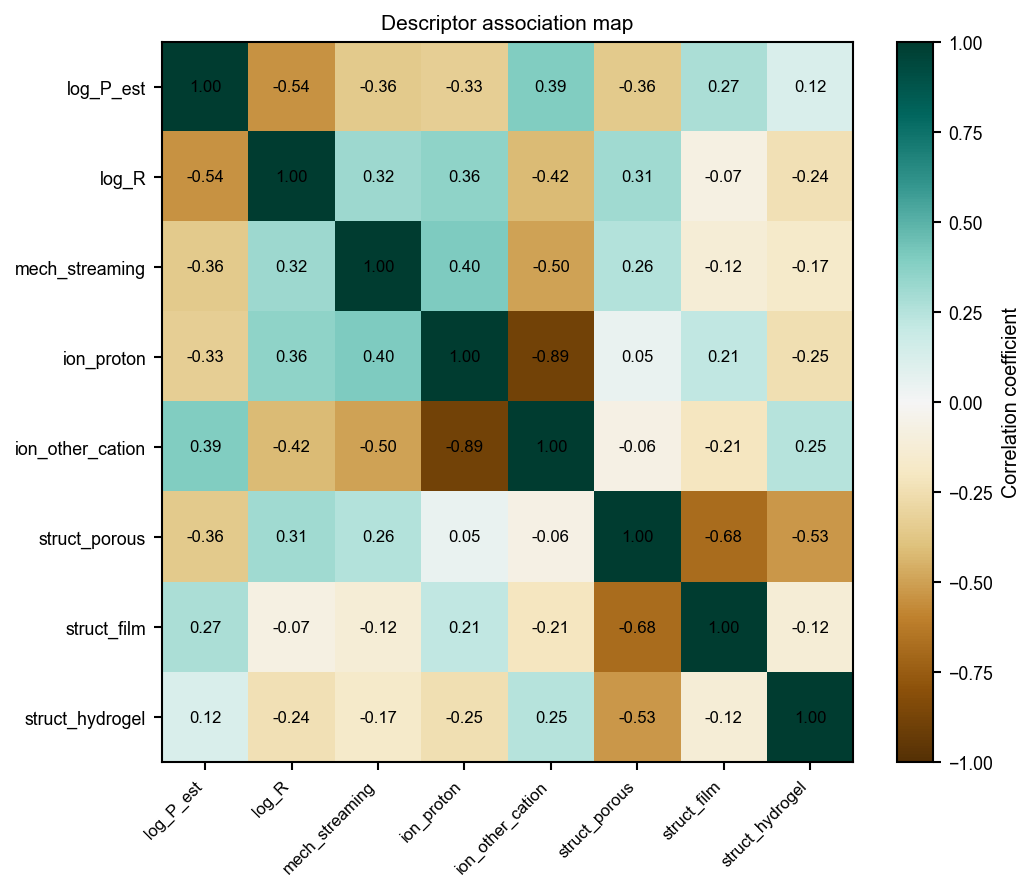

In [97]:
# Draft heatmap for Fig. 2D
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_mat.values, aspect="auto", vmin=-1, vmax=1, cmap="BrBG")
# Ticks
ax.set_xticks(range(len(corr_mat.columns)))
ax.set_yticks(range(len(corr_mat.index)))
ax.set_xticklabels(corr_mat.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_mat.index)

# Title
ax.set_title("Descriptor association map")

# Annotate values
for i in range(corr_mat.shape[0]):
    for j in range(corr_mat.shape[1]):
        val = corr_mat.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Correlation coefficient")

plt.tight_layout()
plt.show()

In [98]:
# Export heatmap matrix for Igor Pro
corr_mat.to_csv(out_dir / "fig2D_descriptor_association_heatmap.csv", encoding="utf-8-sig")

print("Exported:")
print(out_dir / "fig2D_descriptor_association_heatmap.csv")

Exported:
..\results\figure2_dataset_structure\fig2D_descriptor_association_heatmap.csv


In [99]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import TwoSlopeNorm

# =========================
# Output folders
# =========================
fig2_dir = Path("../results/figure2_dataset_structure")
final_dir = fig2_dir / "final_panels"
final_dir.mkdir(parents=True, exist_ok=True)

print("Figure 2 result folder:", fig2_dir.resolve())
print("Final panel output folder:", final_dir.resolve())


# =========================
# Final style
# =========================
COLORS_FINAL = {
    "black": "#000000",
    "dark_gray": "#4D4D4D",
    "gray": "#8C8C8C",
    "light_gray": "#C7C7C7",
    "very_light_gray": "#EFEFEF",
}

# Descriptor palette for Figure 2
# These colors are categorical, not favorable/limited regime colors.
MECH_COLORS = {
    "ion_gradient": "#5B7DB1",   # muted blue
    "streaming": "#A07CB8",      # muted purple
}

ION_COLORS = {
    "proton": "#B08C5A",         # warm brown / khaki
    "other_cation": "#4C9A8A",   # muted teal
    "anion": "#6C8EBF",          # muted blue
}

STRUCTURE_COLORS = {
    "porous": "#B08C5A",             # brown-khaki
    "film": "#6C8EBF",               # muted blue
    "hydrogel": "#4C9A8A",           # muted teal
    "hydrogel + porous": "#A07CB8",  # muted purple
    "hydrogel + film": "#7F7F7F",    # gray
}

SCATTER_SIZE = 14
SCATTER_ALPHA = 0.65
JITTER_SCALE = 0.045


def set_final_style():
    mpl.rcParams.update({
        "font.family": "Arial",
        "font.size": 8.5,
        "font.weight": "normal",

        "mathtext.fontset": "custom",
        "mathtext.rm": "Arial",
        "mathtext.it": "Arial:italic",
        "mathtext.bf": "Arial:bold",

        "axes.linewidth": 1.0,
        "axes.labelsize": 9.5,
        "axes.titlesize": 10,
        "axes.labelweight": "normal",
        "axes.titleweight": "normal",

        "xtick.labelsize": 8.0,
        "ytick.labelsize": 8.5,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,

        "lines.linewidth": 1.2,
        "lines.markersize": 4,

        "legend.fontsize": 7.8,
        "legend.frameon": False,

        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",

        "savefig.dpi": 600,
        "figure.dpi": 150,
        "axes.grid": False,
    })


def format_final_ax(ax, mirror=True):
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
        spine.set_color(COLORS_FINAL["black"])

    ax.spines["top"].set_visible(mirror)
    ax.spines["right"].set_visible(mirror)

    ax.tick_params(
        direction="out",
        width=1.0,
        length=4,
        color=COLORS_FINAL["black"],
        top=False,
        right=False,
    )

    return ax


def save_final_panel(fig, name):
    pdf_path = final_dir / f"{name}.pdf"
    svg_path = final_dir / f"{name}.svg"
    png_path = final_dir / f"{name}.png"

    fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.03)
    fig.savefig(svg_path, bbox_inches="tight", pad_inches=0.03)
    fig.savefig(png_path, dpi=600, bbox_inches="tight", pad_inches=0.03)

    print("Saved:")
    print(" -", pdf_path.name)
    print(" -", svg_path.name)
    print(" -", png_path.name)


set_final_style()


# =========================
# Load exported Figure 2 data
# =========================
fig2A_path = fig2_dir / "fig2A_mechanism_vs_logPest.csv"
fig2B_path = fig2_dir / "fig2B_structure_vs_logPest.csv"
fig2C_path = fig2_dir / "fig2C_iontype_vs_logPest.csv"
fig2D_path = fig2_dir / "fig2D_descriptor_association_heatmap.csv"

required_paths = [fig2A_path, fig2B_path, fig2C_path, fig2D_path]

for p in required_paths:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}. Run the export cell above first.")

fig2A = pd.read_csv(fig2A_path, encoding="utf-8-sig")
fig2B = pd.read_csv(fig2B_path, encoding="utf-8-sig")
fig2C = pd.read_csv(fig2C_path, encoding="utf-8-sig")
fig2D_corr = pd.read_csv(fig2D_path, encoding="utf-8-sig", index_col=0)

print("Loaded final plotting data:")
print(" -", fig2A_path.name, fig2A.shape)
print(" -", fig2B_path.name, fig2B.shape)
print(" -", fig2C_path.name, fig2C.shape)
print(" -", fig2D_path.name, fig2D_corr.shape)

display(fig2A.head())
display(fig2B.head())
display(fig2C.head())
display(fig2D_corr.round(2))

Figure 2 result folder: C:\Users\wenlu\OneDrive\books_coding\Python_Projects\hydrovoltaic-ml\results\figure2_dataset_structure
Final panel output folder: C:\Users\wenlu\OneDrive\books_coding\Python_Projects\hydrovoltaic-ml\results\figure2_dataset_structure\final_panels
Loaded final plotting data:
 - fig2A_mechanism_vs_logPest.csv (159, 2)
 - fig2B_structure_vs_logPest.csv (159, 2)
 - fig2C_iontype_vs_logPest.csv (159, 2)
 - fig2D_descriptor_association_heatmap.csv (8, 8)


,mechanism_simple,log_P_est
0,streaming,-2.425853
1,streaming,-2.698753
2,streaming,-2.027982
3,streaming,-2.106738
4,streaming,-2.795609


,structure_class,log_P_est
0,porous,-2.425853
1,porous,-2.698753
2,porous,-2.027982
3,porous,-2.106738
4,porous,-2.795609


,ion_type,log_P_est
0,proton,-2.425853
1,anion,-2.698753
2,anion,-2.027982
3,proton,-2.106738
4,proton,-2.795609


,log_P_est,log_R,mech_streaming,ion_proton,ion_other_cation,struct_porous,struct_film,struct_hydrogel
log_P_est,1.00,-0.54,-0.36,-0.33,0.39,-0.36,0.27,0.12
log_R,-0.54,1.00,0.32,0.36,-0.42,0.31,-0.07,-0.24
mech_streaming,-0.36,0.32,1.00,0.40,-0.50,0.26,-0.12,-0.17
ion_proton,-0.33,0.36,0.40,1.00,-0.89,0.05,0.21,-0.25
ion_other_cation,0.39,-0.42,-0.50,-0.89,1.00,-0.06,-0.21,0.25
struct_porous,-0.36,0.31,0.26,0.05,-0.06,1.00,-0.68,-0.53
struct_film,0.27,-0.07,-0.12,0.21,-0.21,-0.68,1.00,-0.12
struct_hydrogel,0.12,-0.24,-0.17,-0.25,0.25,-0.53,-0.12,1.00


In [100]:
def plot_hollow_box_colored_scatter(
    ax,
    df,
    group_col,
    value_col,
    order,
    label_map,
    color_map,
    title,
    ylabel=r"$\log(P_{\mathrm{est}})$",
    ylim=(-4.2, 4.2),
    rotate=0,
    show_n=True,
    seed=42,
):
    """
    Final Figure 2 style:
    - colored scatter points as the main data layer
    - hollow boxplot as the summary layer
    - no solid box fill
    """

    d = df.dropna(subset=[group_col, value_col]).copy()

    # Keep only groups present in the data
    order = [g for g in order if g in set(d[group_col])]

    data = [
        d.loc[d[group_col] == g, value_col].dropna().values
        for g in order
    ]

    positions = np.arange(1, len(order) + 1)

    rng = np.random.default_rng(seed)

    # =========================
    # Raw scatter points
    # =========================
    for i, g in enumerate(order, start=1):
        y = d.loc[d[group_col] == g, value_col].dropna().values
        x = rng.normal(loc=i, scale=JITTER_SCALE, size=len(y))

        ax.scatter(
            x,
            y,
            s=SCATTER_SIZE,
            color=color_map[g],
            alpha=SCATTER_ALPHA,
            edgecolor="none",
            zorder=3,
        )

    # =========================
    # Hollow boxplot on top
    # =========================
    box = ax.boxplot(
        data,
        positions=positions,
        widths=0.45,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(
            color=COLORS_FINAL["black"],
            linewidth=1.35,
            zorder=8,
        ),
        boxprops=dict(
            linewidth=1.25,
            color=COLORS_FINAL["black"],
            zorder=7,
        ),
        whiskerprops=dict(
            linewidth=1.25,
            color=COLORS_FINAL["black"],
            zorder=7,
        ),
        capprops=dict(
            linewidth=1.35,
            color=COLORS_FINAL["black"],
            zorder=8,
        ),
    )

    # No solid box fill
    for patch in box["boxes"]:
        patch.set_facecolor("none")
        patch.set_edgecolor(COLORS_FINAL["black"])
        patch.set_linewidth(1.25)
        patch.set_zorder(7)

    for element in ["whiskers", "caps", "medians"]:
        for artist in box[element]:
            artist.set_zorder(8)

    # Reference line: log(P_est) = 0
    ax.axhline(
        0,
        linestyle="--",
        linewidth=1.0,
        color=COLORS_FINAL["light_gray"],
        zorder=1,
    )

    # n labels
    if show_n:
        n_y = ylim[0] + 0.12 * (ylim[1] - ylim[0])

        for i, g in enumerate(order, start=1):
            n = d.loc[d[group_col] == g, value_col].dropna().shape[0]

            ax.text(
                i,
                n_y,
                f"n={n}",
                ha="center",
                va="bottom",
                fontsize=7.5,
                color=COLORS_FINAL["dark_gray"],
                zorder=9,
            )

    labels = [label_map.get(g, g) for g in order]

    ax.set_xticks(positions)
    ax.set_xticklabels(
        labels,
        rotation=rotate,
        ha="right" if rotate else "center",
    )

    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(ylim)

    format_final_ax(ax, mirror=True)

    return ax

Saved:
 - fig2A_final_mechanism_label_vs_performance.pdf
 - fig2A_final_mechanism_label_vs_performance.svg
 - fig2A_final_mechanism_label_vs_performance.png


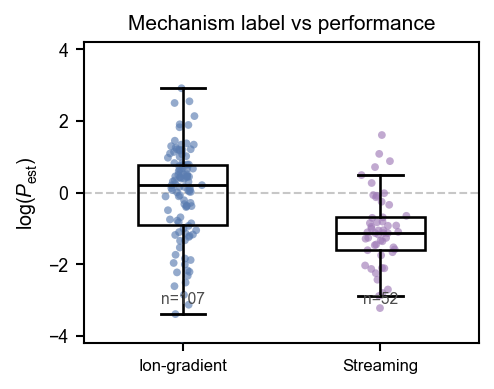

In [101]:
# =========================
# Final Fig. 2A
# Mechanism label vs performance
# =========================

set_final_style()

fig, ax = plt.subplots(figsize=(3.35, 2.65))

mech_order = [
    "ion_gradient",
    "streaming",
]

mech_labels = {
    "ion_gradient": "Ion-gradient",
    "streaming": "Streaming",
}

plot_hollow_box_colored_scatter(
    ax=ax,
    df=fig2A,
    group_col="mechanism_simple",
    value_col="log_P_est",
    order=mech_order,
    label_map=mech_labels,
    color_map=MECH_COLORS,
    title="Mechanism label vs performance",
    ylabel=r"$\log(P_{\mathrm{est}})$",
    ylim=(-4.2, 4.2),
    rotate=0,
    show_n=True,
    seed=42,
)

plt.tight_layout()

save_final_panel(fig, "fig2A_final_mechanism_label_vs_performance")

plt.show()

Saved:
 - fig2B_final_structure_class_vs_performance.pdf
 - fig2B_final_structure_class_vs_performance.svg
 - fig2B_final_structure_class_vs_performance.png


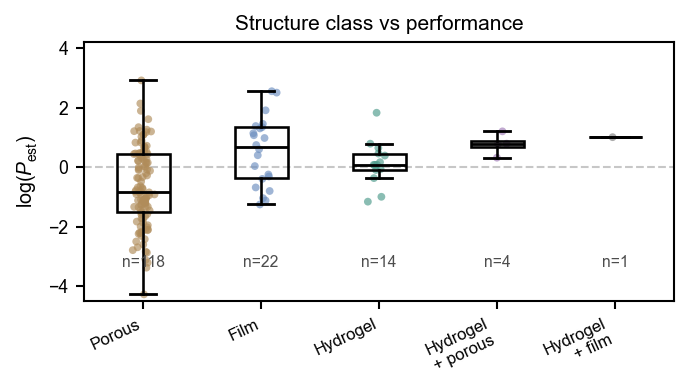

In [102]:
# =========================
# Final Fig. 2B
# Structure class vs performance
# =========================

set_final_style()

fig, ax = plt.subplots(figsize=(4.65, 2.65))

structure_order = [
    "porous",
    "film",
    "hydrogel",
    "hydrogel + porous",
    "hydrogel + film",
]

structure_labels = {
    "porous": "Porous",
    "film": "Film",
    "hydrogel": "Hydrogel",
    "hydrogel + porous": "Hydrogel\n+ porous",
    "hydrogel + film": "Hydrogel\n+ film",
}

plot_hollow_box_colored_scatter(
    ax=ax,
    df=fig2B,
    group_col="structure_class",
    value_col="log_P_est",
    order=structure_order,
    label_map=structure_labels,
    color_map=STRUCTURE_COLORS,
    title="Structure class vs performance",
    ylabel=r"$\log(P_{\mathrm{est}})$",
    ylim=(-4.5, 4.2),
    rotate=25,
    show_n=True,
    seed=42,
)

plt.tight_layout()

save_final_panel(fig, "fig2B_final_structure_class_vs_performance")

plt.show()

Saved:
 - fig2C_final_ion_type_vs_performance.pdf
 - fig2C_final_ion_type_vs_performance.svg
 - fig2C_final_ion_type_vs_performance.png


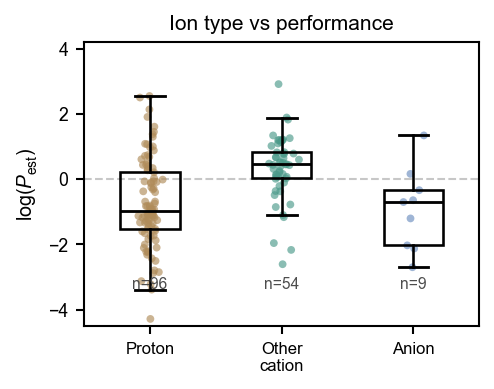

In [103]:
# =========================
# Final Fig. 2C
# Ion type vs performance
# =========================

set_final_style()

fig, ax = plt.subplots(figsize=(3.35, 2.65))

ion_order = [
    "proton",
    "other_cation",
    "anion",
]

ion_labels = {
    "proton": "Proton",
    "other_cation": "Other\ncation",
    "anion": "Anion",
}

plot_hollow_box_colored_scatter(
    ax=ax,
    df=fig2C,
    group_col="ion_type",
    value_col="log_P_est",
    order=ion_order,
    label_map=ion_labels,
    color_map=ION_COLORS,
    title="Ion type vs performance",
    ylabel=r"$\log(P_{\mathrm{est}})$",
    ylim=(-4.5, 4.2),
    rotate=0,
    show_n=True,
    seed=42,
)

plt.tight_layout()

save_final_panel(fig, "fig2C_final_ion_type_vs_performance")

plt.show()

Saved:
 - fig2D_final_descriptor_association_map.pdf
 - fig2D_final_descriptor_association_map.svg
 - fig2D_final_descriptor_association_map.png


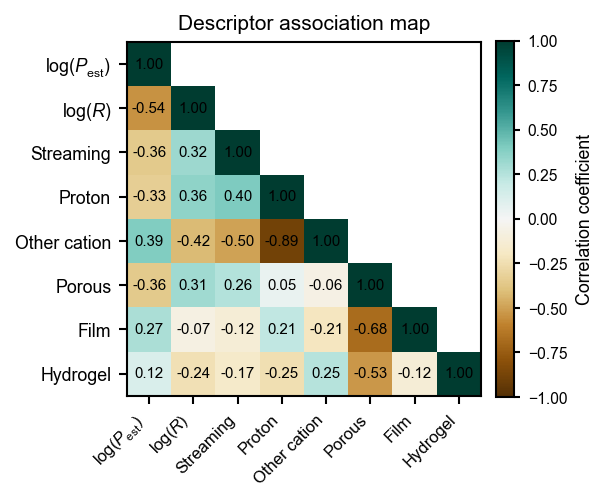

In [104]:
# =========================
# Final Fig. 2D
# Descriptor association map
# =========================

set_final_style()

fig, ax = plt.subplots(figsize=(4.05, 3.65))

corr = fig2D_corr.copy()

label_map = {
    "log_P_est": r"$\log(P_{\mathrm{est}})$",
    "log_R": r"$\log(R)$",
    "mech_streaming": "Streaming",
    "ion_proton": "Proton",
    "ion_other_cation": "Other cation",
    "ion_anion": "Anion",
    "struct_porous": "Porous",
    "struct_film": "Film",
    "struct_hydrogel": "Hydrogel",
}

corr = corr.rename(index=label_map, columns=label_map)

# Lower-triangle heatmap
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
corr_masked = np.ma.array(corr.values, mask=mask)

norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

im = ax.imshow(
    corr_masked,
    cmap="BrBG",
    norm=norm,
    aspect="equal",
)

n = corr.shape[0]

ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))

ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

# Annotate values
for i in range(n):
    for j in range(n):
        if mask[i, j]:
            continue

        val = corr.iloc[i, j]

        if pd.isna(val):
            continue

        ax.text(
            j,
            i,
            f"{val:.2f}",
            ha="center",
            va="center",
            fontsize=7.2,
            color=COLORS_FINAL["black"],
        )

ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(n - 0.5, -0.5)

ax.set_title("Descriptor association map")

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04,
)

cbar.set_label("Correlation coefficient", fontsize=8.5)
cbar.ax.tick_params(labelsize=7.5, width=1.0, length=3)

format_final_ax(ax, mirror=True)

plt.tight_layout()

save_final_panel(fig, "fig2D_final_descriptor_association_map")

plt.show()